## Assignment 3 - Network biology

In [ ]:
# Setup and Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns
from itertools import product
from collections import Counter, defaultdict
import io, contextlib
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

### Helper functions to create a Boolean network (from practical)
Run the following code snippet so the basic functions are available.

In [2]:
# Helper class to build and simulate boolean network

class BooleanNetwork:
    def __init__(self, node_names):
        self.nodes = {name: 0 for name in node_names}
        self.rules = {}
        self.history = []
        self.graph = nx.DiGraph()  # NetworkX graph for visualization

        # Add nodes to NetworkX graph
        self.graph.add_nodes_from(node_names)

    def add_rule(self, target_node, rule_function, rule_description=""):
        """
        Add Boolean rule for a node

        Args:
            target_node: Node to update
            rule_function: Function that takes current state dict and returns True/False
            rule_description: Human-readable description
        """
        self.rules[target_node] = {
            'function': rule_function,
            'description': rule_description
        }

    def set_state(self, **kwargs):
        """Set states of specific nodes"""
        for node, value in kwargs.items():
            if node in self.nodes:
                self.nodes[node] = int(bool(value))

    def get_state_vector(self):
        """Get current state as list in sorted order"""
        return [self.nodes[node] for node in sorted(self.nodes.keys())]

    def update_synchronous(self):
        """Update all nodes simultaneously"""
        new_state = {}
        for node in self.nodes:
            if node in self.rules:
                new_state[node] = int(self.rules[node]['function'](self.nodes))
            else:
                new_state[node] = self.nodes[node]  # No rule = no change

        self.nodes = new_state
        self.history.append(self.get_state_vector())

    def simulate(self, steps=10, record_history=True):
        """Run simulation"""
        if record_history:
            self.history = [self.get_state_vector()]

        for step in range(steps):
            self.update_synchronous()

            # Check for steady state
            if len(self.history) >= 2 and self.history[-1] == self.history[-2]:
                print(f"   Reached steady state after {step+1} steps")
                break

        return np.array(self.history)

## (from practtical) Simplified cell regulatory network

🧬 Biological context

Cells make binary decisions:
* GROW: Divide and multiply (good for healing, bad if uncontrolled)
* DIE: Self-destruct (protective mechanism, prevents cancer)
* REST: Stay inactive (safe default state)

Key molecular switches (think: binary variables):
* DNA_damage: External damage signal (input variable)
* p53: "Tumor suppressor" - master safety switch that detects problems
* MYC: "Oncogene" - growth promoter that drives cell division
* CDK2: Cell division machinery that executes growth
* MDM2: "p53 inhibitor" - blocks p53 function (cancer exploit!)
* p21: "Cell cycle brake" - stops division when problems detected
* Growth/Death: Final binary decisions (outputs)

In [3]:
# Create the regulatory network
nodes = ['DNA_damage', 'p53', 'MYC', 'CDK2', 'MDM2', 'p21', 'Growth', 'Death']
network = BooleanNetwork(nodes)

# Define Boolean rules (based on real biology, simplified)
network.add_rule('DNA_damage', lambda s: s['DNA_damage'],                                       "DNA_damage = INPUT (constant)")
network.add_rule('p21',        lambda s: s['p53'],                                              "p21 = p53")
network.add_rule('MYC',        lambda s: (not s['p53']) and (not s['p21']),                     "MYC = (NOT p53) AND (NOT p21)")
network.add_rule('CDK2',       lambda s: s['MYC'] and (not s['p21']) and (not s['p53']),        "CDK2 = MYC AND (NOT p21) AND (NOT p53)")
network.add_rule('MDM2',       lambda s: s['MYC'],                                              "MDM2 = MYC")
network.add_rule('p53',        lambda s: s['DNA_damage'] and not s['MDM2'],                     "p53 = DNA_damage AND (NOT MDM2)")
network.add_rule('Growth',     lambda s: s['CDK2'] and s['MYC'] and (not s['p53']),             "Growth = CDK2 AND MYC AND (NOT p53)")
network.add_rule('Death',      lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']),    "Death = p53 AND DNA_damage AND (NOT Growth)")

print("Rules:")
for node, rule_info in network.rules.items():
    print(f" {rule_info['description']}")

Rules:
 DNA_damage = INPUT (constant)
 p21 = p53
 MYC = (NOT p53) AND (NOT p21)
 CDK2 = MYC AND (NOT p21) AND (NOT p53)
 MDM2 = MYC
 p53 = DNA_damage AND (NOT MDM2)
 Growth = CDK2 AND MYC AND (NOT p53)
 Death = p53 AND DNA_damage AND (NOT Growth)


For each molecule, add a short description: (suppressed is inhibited) and (Activated is promoted)  
(from practical for reference)
- e.g. MYC is suppressed by both p53 and p21
- p21: Activated directly by p53
- CDK2: Activated by MYC but supressed by both p21 and p53
- MDM2: Activated by MYC 
- p53: Activated by DNA damage and suppressed by MDM2
- DNA damage : This is the input, it is not regulated
- Growth : Activated by CDK2 and MYC and inhibitted by p53
- Death : Activated by P53 and DNA damage and inhibitted by growth

## **Part 1:  Scenario Analysis**

Scenarios:
*   Healthy Cell: `{'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}`
*   Stressed Cell (Repairable): `{'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0,'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}`
*   Oncogene Hijacked Cell: `{'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}`

For each scenario, decide on the final growth, death and p53 state (0 or 1).



In [5]:
# code for healthy cell below, adapt to also run Stressed Cell and Oncogene Hijacked Cell scenarios

scenarios = {
    'Healthy Cell': {'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Stressed Cell': { 'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Oncogene Hijacked Cell': { 'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}
}

results = {}

# Run healthy cell scenario
s = "Healthy Cell"
initial_state = scenarios[s]
network.set_state(**initial_state)
trajectory = network.simulate(steps=8)
results[s] = trajectory

final_state = trajectory[-1]
node_names = sorted(network.nodes.keys())
final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

print(f"   {s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")


# TODO: Repeat for other scenarios!

print("-------------------------------")

for name, initial_state in scenarios.items():
    network.set_state(**initial_state)
    trajectory = network.simulate(steps=8)
    results[name] = trajectory
    final_state = trajectory[-1]
    node_names = sorted(network.nodes.keys())
    final_dict = {node: final_state[name] for name, node in enumerate(node_names)}
    print(f"   {name}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")
    print("\n")

print(results)

   Reached steady state after 4 steps
   Healthy Cell: Final state: Growth=1, Death=0, p53=0
-------------------------------
   Reached steady state after 4 steps
   Healthy Cell: Final state: Growth=1, Death=0, p53=0


   Reached steady state after 6 steps
   Stressed Cell: Final state: Growth=0, Death=1, p53=1


   Reached steady state after 3 steps
   Oncogene Hijacked Cell: Final state: Growth=1, Death=0, p53=0


{'Healthy Cell': array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 1, 1, 0, 0],
       [1, 0, 0, 1, 1, 1, 0, 0],
       [1, 0, 0, 1, 1, 1, 0, 0]]), 'Stressed Cell': array([[0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 1, 0, 1],
       [0, 1, 1, 0, 1, 0, 1, 1],
       [0, 1, 1, 0, 0, 0, 1, 0],
       [0, 1, 0, 0, 0, 0, 0, 1],
       [0, 1, 1, 0, 0, 0, 1, 1],
       [0, 1, 1, 0, 0, 0, 1, 1]]), 'Oncogene Hijacked Cell': array([[0, 0, 0, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 1, 1, 0, 0],
       [1, 0, 0, 1, 1, 1, 0, 0],
       [1, 0, 0, 1, 

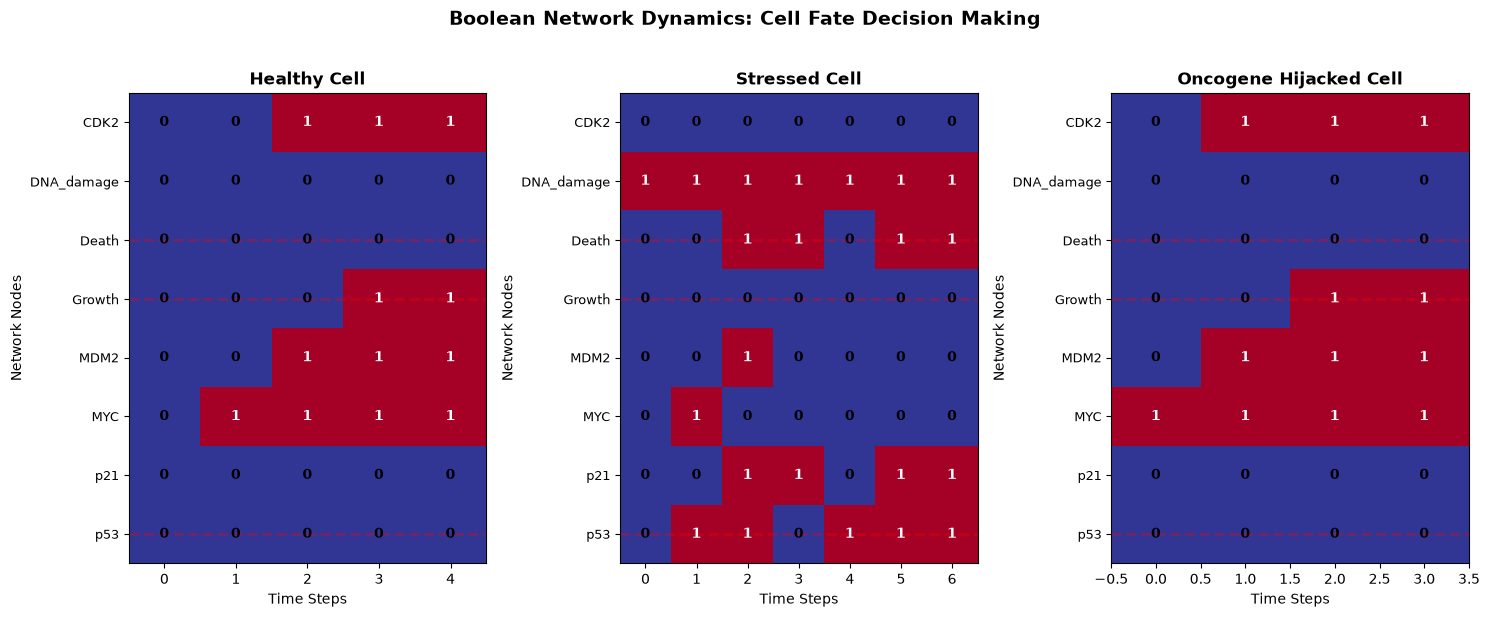

In [ ]:
#  Visualize results
n_scenarios = len(results)
fig, axes = plt.subplots(1, n_scenarios, figsize=(5*n_scenarios, 6))

if n_scenarios == 1:
    axes = [axes]

for scenario_idx, (scenario_name, trajectory) in enumerate(results.items()):
    ax = axes[scenario_idx]

    # Create heatmap
    trajectory_matrix = trajectory.T  # Transpose for proper orientation

    im = ax.imshow(trajectory_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest', vmin=0, vmax=1)

    # Formatting
    ax.set_title(f'{scenario_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Network Nodes', fontsize=10)
    ax.set_yticks(range(len(node_names)))
    ax.set_yticklabels(node_names, fontsize=9)

    # Add text annotations
    for t in range(trajectory.shape[0]):
        for n in range(len(node_names)):
            color = 'white' if trajectory_matrix[n, t] == 1 else 'black'
            ax.text(t, n, int(trajectory_matrix[n, t]),
                   ha="center", va="center", color=color, fontweight='bold')

    # Highlight key output nodes
    output_indices = [i for i, name in enumerate(node_names) if name in ['Growth', 'Death', 'p53']]
    for output_idx in output_indices:  # Changed variable name to avoid conflict
        ax.axhline(y=output_idx, color='red', linestyle='--', alpha=0.3, linewidth=2)

plt.suptitle('Boolean Network Dynamics: Cell Fate Decision Making',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---

## **Part 3: Attractor analysis**

Attractors = stable states the network eventually reaches from any starting point

Types:
* Fixed Point: Network stops changing (steady state)
* Limit Cycle: Network oscillates in repeating pattern  

Why is this important?
* Represent system's natural 'destinations'
* Can predict long-term behavior
* Identify stable patterns in system
* Design interventions to reach desired attractors

In [ ]:
# Let's find the attractor states 

attractors = []
max_steps=15
node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

print(f"Testing all {2**n_nodes} possible initial states...")

# TODO: Generate all possible initial states
# Hint: Use itertools.product([0, 1], repeat=n_nodes)
all_states = product([0,1], repeat=n_nodes)

for initial_state in all_states:
  # Set the network to this initial state
  state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
  network.set_state(**state_dict)

  # TODO: Simulate the network
  trajectory = network.simulate(steps=max_steps)

  # Check if it reached a steady state (last two states are the same)
  if len(trajectory) >= 2:
    final_state = tuple(trajectory[-1])  # Convert to tuple for comparison

  # Check if this is a new attractor
    if np.array_equal(trajectory[-1], trajectory[-2]):  # Steady state reached
      if final_state not in attractors:
        attractors.append(final_state)

Testing all 256 possible initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reac


FOUND 3 ATTRACTORS:

Attractor 1: [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: OFF
   → 

Attractor 2: [np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]
   Growth: OFF
   Death: ON
   p53: ON
   DNA Damage: ON
   → 

Attractor 3: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: ON
   → 


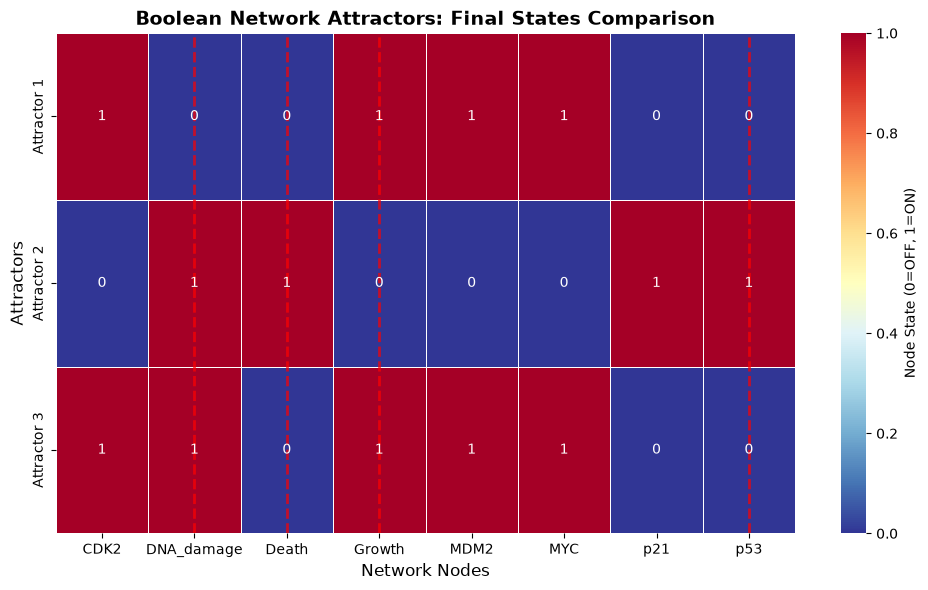

In [ ]:
#  Let's find the attractor states

print(f"\nFOUND {len(attractors)} ATTRACTORS:")

for i, attractor in enumerate(attractors):
        print(f"\nAttractor {i+1}: {list(attractor)}")

        # Create state dictionary for easy access
        state_dict = {node_names[j]: attractor[j] for j in range(len(node_names))}

        # Analyze the biological meaning
        growth_active = state_dict['Growth'] == 1
        death_active = state_dict['Death'] == 1
        p53_active = state_dict['p53'] == 1
        dna_damage_active = state_dict['DNA_damage'] == 1


        print(f"   Growth: {'ON' if growth_active else 'OFF'}")
        print(f"   Death: {'ON' if death_active else 'OFF'}")
        print(f"   p53: {'ON' if p53_active else 'OFF'}")
        print(f"   DNA Damage: {'ON' if dna_damage_active else 'OFF'}")

        # TODO: Interpret the meaning
        if growth_active and not death_active and not dna_damage_active:
            interpretation = ""
        elif death_active and not growth_active:
            interpretation = ""
        elif growth_active and not death_active and dna_damage_active:
            interpretation = ""
        else:
            interpretation = "CONFLICT - Unusual state"

        print(f"   → {interpretation}")


# Convert attractors to clean matrix
attractor_matrix = []
for attractor in attractors:
    clean_row = [int(x) for x in attractor]
    attractor_matrix.append(clean_row)

attractor_matrix = np.array(attractor_matrix)

# Create heatmap
plt.figure(figsize=(10, max(6, len(attractors))))

# Create heatmap with custom colors
ax = sns.heatmap(attractor_matrix,
                 xticklabels=node_names,
                 yticklabels=[f'Attractor {i+1}' for i in range(len(attractors))],
                 cmap='RdYlBu_r',
                 cbar_kws={'label': 'Node State (0=OFF, 1=ON)'},
                 annot=True,
                 fmt='d',
                 linewidths=0.5)

plt.title('Boolean Network Attractors: Final States Comparison',
          fontsize=14, fontweight='bold')
plt.xlabel('Network Nodes', fontsize=12)
plt.ylabel('Attractors', fontsize=12)

# Highlight key output nodes
output_nodes = ['Growth', 'Death', 'p53', 'DNA_damage']
for node in output_nodes:
    if node in node_names:
        idx = node_names.index(node)
        ax.axvline(x=idx+0.5, color='red', linestyle='--', alpha=0.7, linewidth=2)

plt.tight_layout()
plt.show()

Analyzing 256 initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady 

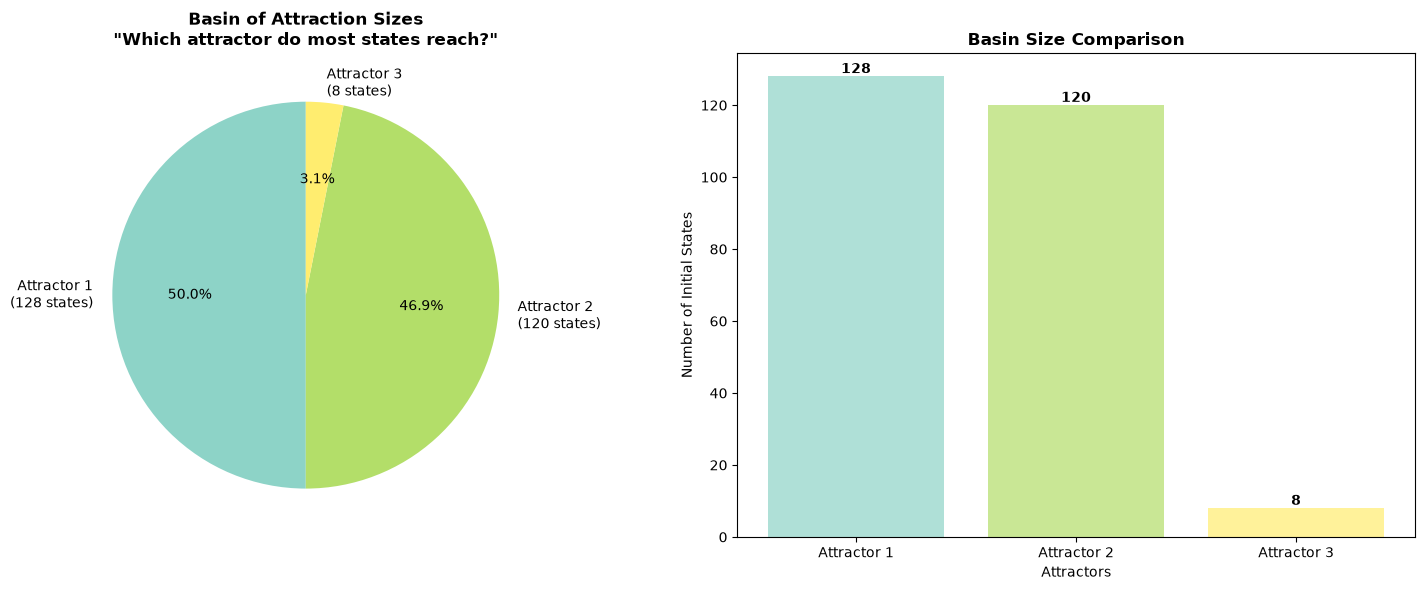

In [ ]:
#  Which states end up in which attractor?

# Track which initial states lead to which attractors
basin_data = defaultdict(list)  # attractor -> list of initial states
attractor_map = {}  # initial_state -> attractor_index

n_nodes = len(node_names)
all_states = list(product([0, 1], repeat=n_nodes))
print(f"Analyzing {len(all_states)} initial states...")

for initial_state in all_states:
    # Set network state
    state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
    network.set_state(**state_dict)

    # Simulate
    trajectory = network.simulate(steps=max_steps, record_history=True)

    # Find which attractor this leads to
    if len(trajectory) >= 2 and np.array_equal(trajectory[-1], trajectory[-2]):
        final_state = tuple(int(x) for x in trajectory[-1])  # Clean conversion

        # Find matching attractor
        for att_idx, attractor in enumerate(attractors):
            clean_attractor = tuple(int(x) for x in attractor)
            if final_state == clean_attractor:
                basin_data[att_idx].append(initial_state)
                attractor_map[initial_state] = att_idx
                break

# Display basin sizes
print(f"\n Basin Sizes:")
total_states = len(all_states)
for att_idx in range(len(attractors)):
    basin_size = len(basin_data[att_idx])
    percentage = (basin_size / total_states) * 100
    print(f"   Attractor {att_idx+1}: {basin_size:3d} states ({percentage:5.1f}%)")

# Create pie chart of basin sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart of basin sizes
basin_sizes = [len(basin_data[i]) for i in range(len(attractors))]
basin_labels = [f'Attractor {i+1}\n({size} states)' for i, size in enumerate(basin_sizes)]
colors = plt.cm.Set3(np.linspace(0, 1, len(attractors)))

wedges, texts, autotexts = ax1.pie(basin_sizes,
                                   labels=basin_labels,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)

ax1.set_title('Basin of Attraction Sizes\n"Which attractor do most states reach?"',
              fontsize=12, fontweight='bold')

# Bar chart comparison
attractor_names = [f'Attractor {i+1}' for i in range(len(attractors))]
bars = ax2.bar(attractor_names, basin_sizes, color=colors, alpha=0.7)

ax2.set_title('Basin Size Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Initial States', fontsize=10)
ax2.set_xlabel('Attractors', fontsize=10)

# Add value labels on bars
for bar, size in zip(bars, basin_sizes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{size}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

 small note:  

  Would be nice to make scenario analysis and attractor analysis into functions    
    
  Then we can individually for each mutations do the change and at every step we can monitor it and give results which will be easier to monitor and record the values 

# **Part 2: Mutation Analysis**

### Analysis of the 5 different mutations below:

We test the **Normal** network plus **5 mutated networks**: the three given mutations (A, B, C) and **two of our own choice** (D, E).  
  
Mutation A: p53 Knockout (Loss of tumor suppressor):  
>network.add_rule('p53', lambda s: False, "p53 = BROKEN (always OFF)")

Mutation B: MYC Amplification (Oncogene overexpression):  
>network.add_rule('MYC', lambda s: True, "MYC = AMPLIFIED (always ON)")

Mutation C: MDM2 Overexpression (p53 pathway disruption):  
>network.add_rule('MDM2', lambda s: True, "MDM2 = OVEREXPRESSED (always ON)")

Mutation D: DNA Damage (Chronic Condition):
>net.add_rule('DNA_damage', lambda s: True, "DNA_damage = CHRONIC (always ON)")

Mutation E: Unrestricted Growth (Unregulated Cell Division):
>net.add_rule('Growth', lambda s: True, "Growth = LOCKED ON (always ON)") 


In [20]:
def build_normal_network():
    """Builds the baseline (non-mutated) regulatory network, exactly as in the practical."""
    nodes = ['DNA_damage', 'p53', 'MYC', 'CDK2', 'MDM2', 'p21', 'Growth', 'Death']
    net = BooleanNetwork(nodes)
    net.add_rule('DNA_damage', lambda s: s['DNA_damage'],                                  "DNA_damage = INPUT (constant)")
    net.add_rule('p21',        lambda s: s['p53'],                                         "p21 = p53")
    net.add_rule('MYC',        lambda s: (not s['p53']) and (not s['p21']),                "MYC = (NOT p53) AND (NOT p21)")
    net.add_rule('CDK2',       lambda s: s['MYC'] and (not s['p21']) and (not s['p53']),   "CDK2 = MYC AND (NOT p21) AND (NOT p53)")
    net.add_rule('MDM2',       lambda s: s['MYC'],                                         "MDM2 = MYC")
    net.add_rule('p53',        lambda s: s['DNA_damage'] and not s['MDM2'],                "p53 = DNA_damage AND (NOT MDM2)")
    net.add_rule('Growth',     lambda s: s['CDK2'] and s['MYC'] and (not s['p53']),        "Growth = CDK2 AND MYC AND (NOT p53)")
    net.add_rule('Death',      lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']), "Death = p53 AND DNA_damage AND (NOT Growth)")
    return net


def build_mutated_network(mutation):
    """Returns a fresh network with the requested mutation applied on top of the normal rule set.

    mutation: one of 'Normal', 'A', 'B', 'C', 'D', 'E'
    """
    net = build_normal_network()
    if mutation == 'Normal':
        pass
    elif mutation == 'A':
        net.add_rule('p53', lambda s: False, "p53 = BROKEN (always OFF)")                    # p53 Knockout
    elif mutation == 'B':
        net.add_rule('MYC', lambda s: True, "MYC = AMPLIFIED (always ON)")                   # MYC Amplification
    elif mutation == 'C':
        net.add_rule('MDM2', lambda s: True, "MDM2 = OVEREXPRESSED (always ON)")             # MDM2 Overexpression
    elif mutation == 'D':
        net.add_rule('DNA_damage', lambda s: True, "DNA_damage = CHRONIC (always ON)")       # our choice #1
    elif mutation == 'E':
        net.add_rule('Growth', lambda s: True, "Growth = LOCKED ON (always ON)")             # our choice #2
    else:
        raise ValueError(f"Unknown mutation: {mutation}")
    return net


mutation_labels = {
    'Normal': 'Normal (wild-type)',
    'A': 'Mutation A: p53 Knockout',
    'B': 'Mutation B: MYC Amplification',
    'C': 'Mutation C: MDM2 Overexpression',
    'D': 'Mutation D: DNA_damage Chronic (our choice)',
    'E': 'Mutation E: Growth Locked ON (our choice)',
}
print("Networks ready:", list(mutation_labels.values()))

Networks ready: ['Normal (wild-type)', 'Mutation A: p53 Knockout', 'Mutation B: MYC Amplification', 'Mutation C: MDM2 Overexpression', 'Mutation D: DNA_damage Chronic (our choice)', 'Mutation E: Growth Locked ON (our choice)']


In [ ]:
def run_scenario_analysis(net, steps=20):
    """Runs the 3 standard scenarios on a network and returns final Growth/Death/p53/MYC/MDM2 states.
    steps=20 (slower-convergence), like chronic DNA damage, have time to settle
    into their true attractor"""
    node_names = sorted(net.nodes.keys())
    out = {}
    with contextlib.redirect_stdout(io.StringIO()):  # silence the "Reached steady state..." prints
        for name, init in scenarios.items():
            net.set_state(**init)
            trajectory = net.simulate(steps=steps)
            final = {node_names[i]: int(trajectory[-1][i]) for i in range(len(node_names))}
            out[name] = final
    return out


def run_attractor_analysis(net, max_steps=20):
    """Exhaustively tests every possible initial state (2^8 = 256), finds every attractor
    reached, and records the basin size (number of initial states) for each attractor.
    Returns: node_names, list of attractor tuples, dict{attractor_tuple: basin_size}, total_states
    """
    node_names = sorted(net.nodes.keys())
    n_nodes = len(node_names)
    found_attractors = []
    basin_counts = defaultdict(int)

    with contextlib.redirect_stdout(io.StringIO()):  # silence the "Reached steady state..." prints
        for initial_state in product([0, 1], repeat=n_nodes):
            state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
            net.set_state(**state_dict)
            trajectory = net.simulate(steps=max_steps)

            final_state = tuple(int(x) for x in trajectory[-1])
            reached_fixed_point = len(trajectory) >= 2 and tuple(int(x) for x in trajectory[-2]) == final_state

            if reached_fixed_point:
                if final_state not in found_attractors:
                    found_attractors.append(final_state)
                basin_counts[final_state] += 1
            else:
                # Didn't settle into a fixed point within max_steps; bucket separately but still counted.
                basin_counts[('CYCLE',) + final_state] += 1

    return node_names, found_attractors, basin_counts, 2 ** n_nodes


def cancer_like_fraction(node_names, basin_counts, total_states):
    """Fraction of ALL initial states whose long-term fate is a cancer-like state:
    DNA_damage=1 AND Growth=1 AND Death=0 (dividing despite unrepaired damage, apoptosis fails)."""
    dna_idx, growth_idx, death_idx = (node_names.index(n) for n in ('DNA_damage', 'Growth', 'Death'))
    cancer_states = 0
    for key, count in basin_counts.items():
        state = key[1:] if key[0] == 'CYCLE' else key
        if state[dna_idx] == 1 and state[growth_idx] == 1 and state[death_idx] == 0:
            cancer_states += count
    return cancer_states, total_states, 100 * cancer_states / total_states

### Run scenario analysis + attractor analysis for Normal network and all 5 mutations

In [21]:
mutation_results = {}

for mut in ['Normal', 'A', 'B', 'C', 'D', 'E']:
    net = build_mutated_network(mut)
    scenario_out = run_scenario_analysis(net)

    net2 = build_mutated_network(mut)  # fresh copy so attractor search starts clean
    node_names, attractor_list, basin_counts, total_states = run_attractor_analysis(net2)
    cancer_n, total_n, cancer_pct = cancer_like_fraction(node_names, basin_counts, total_states)

    mutation_results[mut] = {
        'label': mutation_labels[mut],
        'scenarios': scenario_out,
        'node_names': node_names,
        'attractors': attractor_list,
        'basin_counts': basin_counts,
        'total_states': total_states,
        'cancer_states': cancer_n,
        'cancer_pct': cancer_pct,
    }

    print(f"{mutation_labels[mut]:42s}  #attractors={len(attractor_list)}  "
          f"cancer-like basin={cancer_n}/{total_states} ({cancer_pct:.2f}%)")

   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached s

### Scenario analysis: final Growth / Death / p53 for each network

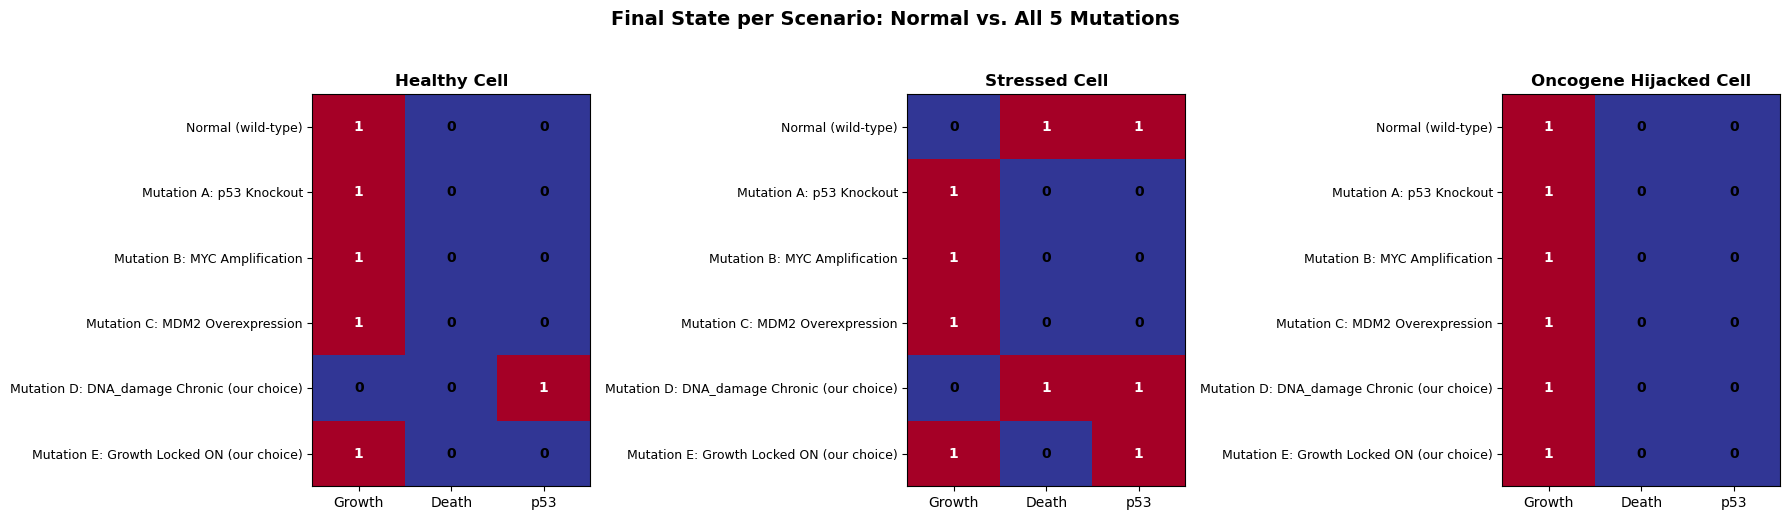

In [ ]:
# Build a small 3D array: [network, scenario, metric] so it can be shown as 3 heatmaps side by side
network_order = ['Normal', 'A', 'B', 'C', 'D', 'E']
scenario_order = list(scenarios.keys())
metrics = ['Growth', 'Death', 'p53']

fig, axes = plt.subplots(1, len(scenario_order), figsize=(6 * len(scenario_order), 5))

for ax, sname in zip(axes, scenario_order):
    matrix = np.array([[mutation_results[m]['scenarios'][sname][metric] for metric in metrics]
                        for m in network_order])
    im = ax.imshow(matrix, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')
    ax.set_title(sname, fontweight='bold')
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics)
    ax.set_yticks(range(len(network_order)))
    ax.set_yticklabels([mutation_labels[m] for m in network_order], fontsize=9)
    for i in range(len(network_order)):
        for j in range(len(metrics)):
            val = matrix[i, j]
            ax.text(j, i, int(val), ha='center', va='center',
                    color='white' if val == 1 else 'black', fontweight='bold')

plt.suptitle('Final State per Scenario: Normal vs. All 5 Mutations', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### Cancer-like basin size: Normal vs. all 5 mutations

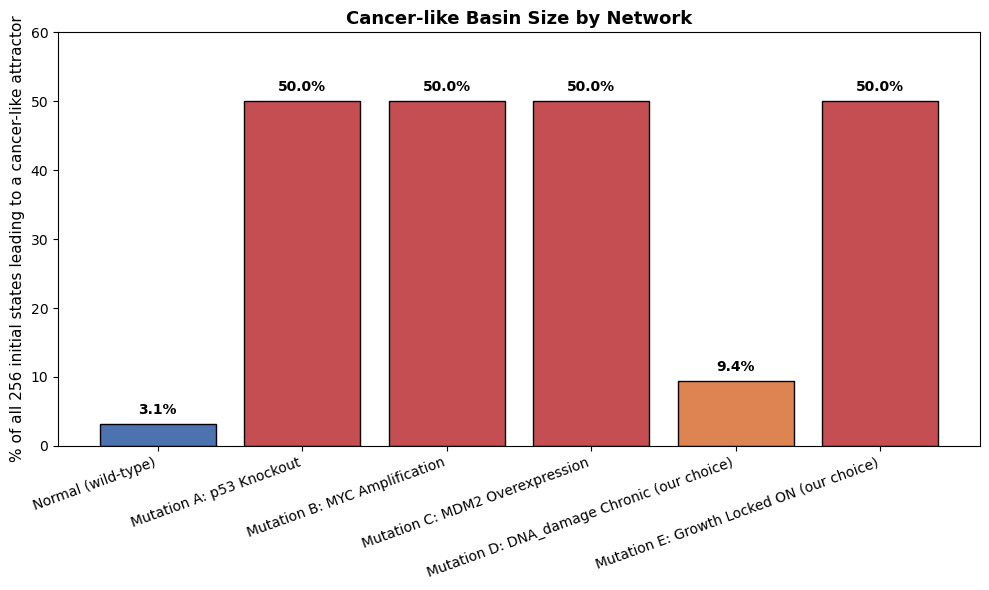

In [ ]:
pcts = [mutation_results[m]['cancer_pct'] for m in network_order]
colors_bar = ['#4C72B0' if m == 'Normal' else ('#C44E52' if pcts[i] >= 40 else '#DD8452')
              for i, m in enumerate(network_order)]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar([mutation_labels[m] for m in network_order], pcts, color=colors_bar, edgecolor='black')
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{pct:.1f}%",
            ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('% of all 256 initial states leading to a cancer-like attractor', fontsize=11)
ax.set_title('Cancer-like Basin Size by Network', fontsize=13, fontweight='bold')
ax.set_ylim(0, 60)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### All attractors across Normal and all 5 mutations

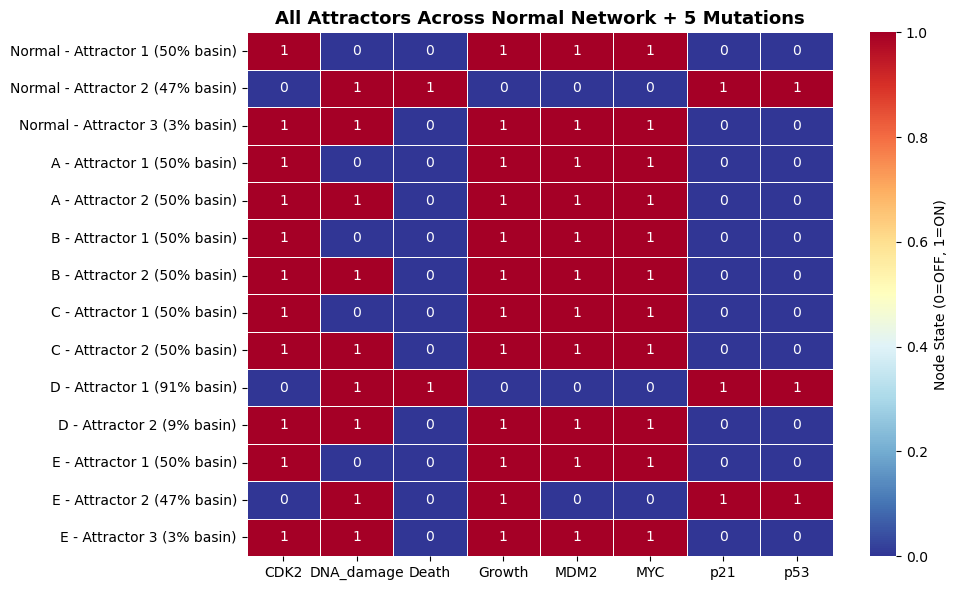

In [ ]:
all_rows, row_labels = [], []
for mut in network_order:
    node_names = mutation_results[mut]['node_names']
    for i, att in enumerate(mutation_results[mut]['attractors']):
        all_rows.append(list(att))
        basin = mutation_results[mut]['basin_counts'].get(att, 0)
        pct = 100 * basin / mutation_results[mut]['total_states']
        row_labels.append(f"{mut} - Attractor {i+1} ({pct:.0f}% basin)")

all_matrix = np.array(all_rows)
node_names_ref = mutation_results['Normal']['node_names']

plt.figure(figsize=(10, max(6, 0.4 * len(row_labels))))
sns.heatmap(all_matrix, xticklabels=node_names_ref, yticklabels=row_labels,
            cmap='RdYlBu_r', cbar_kws={'label': 'Node State (0=OFF, 1=ON)'},
            annot=True, fmt='d', linewidths=0.5)
plt.title('All Attractors Across Normal Network + 5 Mutations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- **Mutations A, B, C and E** all push the cancer-like basin to the *same* value and all wipe out the
  apoptosis attractor — even though they intervene at four different nodes, they all end up forcing the same
  broken outcome (p53 permanently OFF, or its effect permanently overridden).
- **Mutation D** (chronic DNA damage) gives a smaller, more modest increase — the rest of the circuit can
  often still respond correctly even when the damage signal never turns off, it just fails more often than
  Normal.

## **Extra: Every possible single-node knockout / overexpression**

Rather than just A–E, we can systematically test **every node, forced OFF (knockout) and forced ON
(overexpression)** — 8 nodes x 2 directions = 16 single-node mutations — using the same
`build_normal_network()` + `run_attractor_analysis()` + `cancer_like_fraction()` machinery from above.

In [25]:
def build_forced_network(node, forced_value):
    """Same idea as build_mutated_network, but generic: force ANY node to a constant value."""
    net = build_normal_network()
    net.add_rule(node, (lambda v: (lambda s: v))(forced_value), f"{node} = FORCED {forced_value}")
    return net


all_nodes = sorted(build_normal_network().nodes.keys())
sweep_rows = []

for node in all_nodes:
    for forced in [False, True]:
        net = build_forced_network(node, forced)
        node_names, attractor_list, basin_counts, total_states = run_attractor_analysis(net)
        cancer_n, total_n, cancer_pct = cancer_like_fraction(node_names, basin_counts, total_states)
        sweep_rows.append({
            'Node': node,
            'Direction': 'Knockout (OFF)' if not forced else 'Overexpression (ON)',
            'Num_Attractors': len(attractor_list),
            'Cancer_like_pct': cancer_pct,
        })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 2 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 1 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 2 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached s

,Node,Direction,Num_Attractors,Cancer_like_pct
0,CDK2,Knockout (OFF),3,0.000
1,CDK2,Overexpression (ON),3,3.125
2,DNA_damage,Knockout (OFF),1,0.000
3,DNA_damage,Overexpression (ON),2,9.375
4,Death,Knockout (OFF),3,3.125
5,Death,Overexpression (ON),3,0.000
6,Growth,Knockout (OFF),3,0.000
7,Growth,Overexpression (ON),3,50.000
8,MDM2,Knockout (OFF),2,0.000
9,MDM2,Overexpression (ON),2,50.000


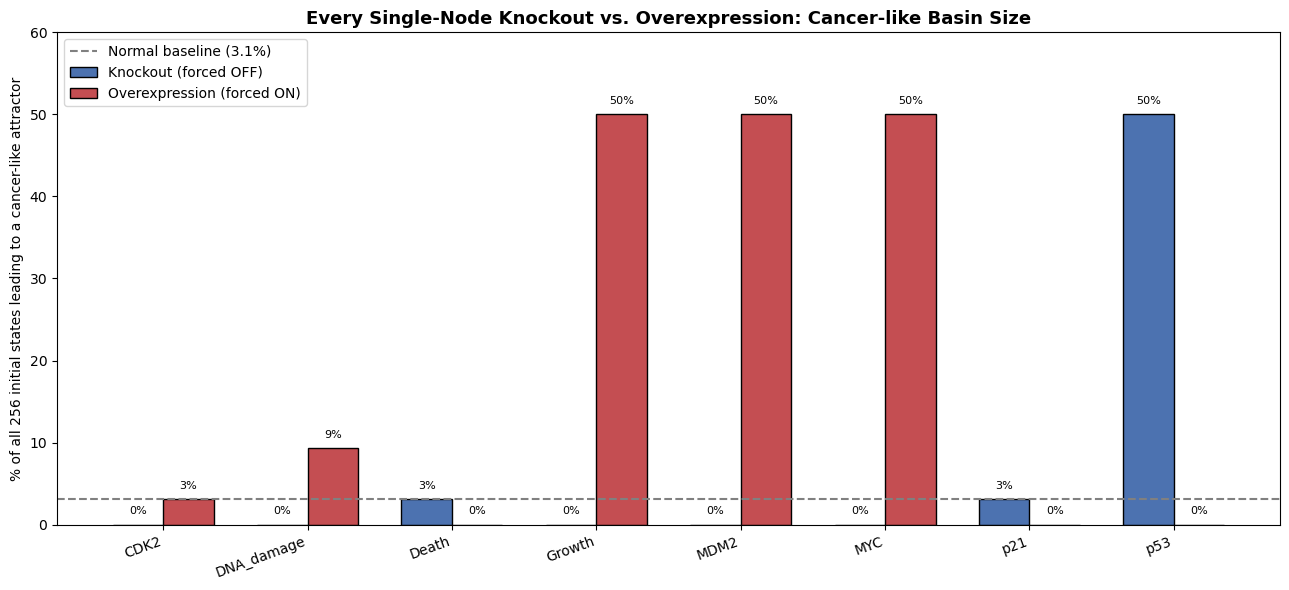

In [ ]:
baseline_pct = mutation_results['Normal']['cancer_pct']

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(all_nodes))
width = 0.35

ko_pcts = [sweep_df[(sweep_df.Node == n) & (sweep_df.Direction == 'Knockout (OFF)')]['Cancer_like_pct'].values[0]
           for n in all_nodes]
ov_pcts = [sweep_df[(sweep_df.Node == n) & (sweep_df.Direction == 'Overexpression (ON)')]['Cancer_like_pct'].values[0]
           for n in all_nodes]

bars1 = ax.bar(x - width/2, ko_pcts, width, label='Knockout (forced OFF)', color='#4C72B0', edgecolor='black')
bars2 = ax.bar(x + width/2, ov_pcts, width, label='Overexpression (forced ON)', color='#C44E52', edgecolor='black')

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.0f}%", ha='center', va='bottom', fontsize=8)

ax.axhline(baseline_pct, color='gray', linestyle='--', linewidth=1.5,
           label=f'Normal baseline ({baseline_pct:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(all_nodes, rotation=20, ha='right')
ax.set_ylabel('% of all 256 initial states leading to a cancer-like attractor')
ax.set_title('Every Single-Node Knockout vs. Overexpression: Cancer-like Basin Size', fontsize=13, fontweight='bold')
ax.set_ylim(0, 60)
ax.legend()
plt.tight_layout()
plt.show()